# ➕ Transformer That Learns Arithmetic
### Teaching a transformer to compute: digit carries, precedence, algebra, and grokking

**What this notebook covers:**
1. Why arithmetic is the ideal transformer test-bed
2. Character-level tokenizer designed for math
3. Synthetic dataset: infinite, perfectly labelled
4. The Grokking phenomenon — delayed generalisation in neural networks
5. Transformer model with answer-only loss
6. Training to high accuracy (+80% exact match)
7. What each attention head learns about arithmetic
8. Failure analysis — where and why the model makes mistakes
9. Modular arithmetic — the canonical grokking experiment

> All cells run in order. GPU recommended but not required (CPU trains in ~10 min).


---
## 🧠 Section 0 — Why Arithmetic is the Perfect Test-Bed

Natural language modelling has a problem: we can never be sure whether a model
*understands* or just *memorises* statistical patterns from training data.

Arithmetic is different:

| Property | Natural language | Arithmetic |
|---|---|---|
| Labels | subjective / ambiguous | perfectly deterministic |
| Data | finite (internet has limits) | infinite (generate forever) |
| Evaluation | fuzzy (BLEU, perplexity) | exact match (0 or 1) |
| Generalisation | hard to test cleanly | test on held-out number pairs |
| Reasoning required | maybe | definitely |

This makes arithmetic a **clean scientific instrument** for studying whether transformers
can learn algorithms, not just memorise.

### The Grokking Phenomenon

In 2022, Power et al. ("Grokking: Generalisation Beyond Overfitting") found something surprising:

> A transformer trained on modular arithmetic first **memorises** the training set
> (val accuracy stays near 0%), then — after thousands more steps — suddenly **generalises**
> (val accuracy jumps to ~100% within a few hundred steps).

This delayed generalisation ("grokking") suggests the model eventually finds a compact
algorithmic solution rather than a lookup table. We reproduce this in Section 9.

### What the model must learn for digit arithmetic

- **Addition**: right-to-left digit processing, carry propagation
- **Subtraction**: borrow propagation
- **Multiplication**: the × table plus partial products and summation
- **Operator precedence**: multiply before adding in `3+4*5`
- **Algebra**: symbolic rearrangement `x+12=30` → `x=30-12`

These require compositional reasoning over individual digit tokens — not surface pattern matching.


## ⚙️ Setup

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math, random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from torch.utils.data import Dataset, DataLoader
from collections import defaultdict

random.seed(42)
torch.manual_seed(42)
np.random.seed(42)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')
if device == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')


Device: cpu


---
## 📝 Section 1 — Math Tokenizer

### Design decisions

**Why character-level?**
The model needs to reason about individual digits to handle carries and borrows correctly.
If `47` were a single token, the model could not learn the carry from units to tens —
it would have to memorise the answer for every two-digit pair separately.

**Why not BPE?**
BPE merges frequent character pairs. For math, `12` might become a single token, making it
impossible for the model to learn positional digit structure.

**Special tokens:**
- `[PAD]` — fills sequences to uniform length in a batch
- `[ANS]` — boundary between problem and answer: `23+47[ANS]70[EOS]`
- `[EOS]` — signals the model to stop generating

The `[ANS]` separator is crucial. Without it the model must decide itself where the problem
ends and the answer begins — much harder. With it, we're telling the model: *"everything up
to here is context; everything after is what you must compute."*

**Total vocabulary: 22 tokens** (10 digits + 8 operators/special chars + 3 special tokens + space)


In [2]:
DIGITS   = list('0123456789')
OPS      = list('+-*/=,x ')
SPECIAL  = ['[PAD]', '[ANS]', '[EOS]']
ALL_TOKS = DIGITS + OPS + SPECIAL

stoi     = {t: i for i, t in enumerate(ALL_TOKS)}
itos     = {i: t for t, i in stoi.items()}
PAD_ID   = stoi['[PAD]']
ANS_ID   = stoi['[ANS]']
EOS_ID   = stoi['[EOS]']
VOCAB    = len(stoi)

def encode(s):
    """String → token ids. Skips unknown characters."""
    return [stoi[c] for c in str(s) if c in stoi]

def decode(ids, strip_special=True):
    """Token ids → string."""
    result = []
    for i in ids:
        t = itos.get(i, '?')
        if strip_special and t in ('[PAD]', '[EOS]', '[ANS]'): continue
        result.append(t)
    return ''.join(result)

print(f'Vocabulary ({VOCAB} tokens):')
for i in range(VOCAB):
    print(f'  {i:2d}: {itos[i]!r}', end='   ')
    if (i+1) % 5 == 0: print()
print()

# Demo encoding
for prob, ans in [('23+47', '70'), ('8*9', '72'), ('x+12=30,x', '18')]:
    ids = encode(prob) + [ANS_ID] + encode(ans) + [EOS_ID]
    print(f'  {prob}[ANS]{ans}[EOS]')
    print(f'    ids:    {ids}')
    print(f'    tokens: {[itos[i] for i in ids]}')
    print()


Vocabulary (21 tokens):
   0: '0'      1: '1'      2: '2'      3: '3'      4: '4'   
   5: '5'      6: '6'      7: '7'      8: '8'      9: '9'   
  10: '+'     11: '-'     12: '*'     13: '/'     14: '='   
  15: ','     16: 'x'     17: ' '     18: '[PAD]'     19: '[ANS]'   
  20: '[EOS]'   
  23+47[ANS]70[EOS]
    ids:    [2, 3, 10, 4, 7, 19, 7, 0, 20]
    tokens: ['2', '3', '+', '4', '7', '[ANS]', '7', '0', '[EOS]']

  8*9[ANS]72[EOS]
    ids:    [8, 12, 9, 19, 7, 2, 20]
    tokens: ['8', '*', '9', '[ANS]', '7', '2', '[EOS]']

  x+12=30,x[ANS]18[EOS]
    ids:    [16, 10, 1, 2, 14, 3, 0, 15, 16, 19, 1, 8, 20]
    tokens: ['x', '+', '1', '2', '=', '3', '0', ',', 'x', '[ANS]', '1', '8', '[EOS]']



---
## ♾️ Section 2 — Infinite Math Data Generator

We generate problems procedurally — no dataset to download, no labels to write.

### Problem format

```
<problem> [ANS] <answer> [EOS]
```

The model is trained to predict every next token. But we compute **loss only on the answer
tokens** — the positions after `[ANS]`. This focuses the gradient signal entirely on
whether the model can *compute* the correct answer, not on whether it can reproduce the problem.

### Curriculum — start easy, add complexity

Training on a mix of difficulties from the start can slow convergence.
We use a mild curriculum: single-digit problems appear more often early in training.


Sample problems by type:
  [arithmetic] 80+33 [ANS] 113
  [arithmetic] x+29=60,x [ANS] 31
  [arithmetic] 66*63 [ANS] 4158
  [multi-step] 38-24 [ANS] 14
  [multi-step] 28-87 [ANS] -59
  [multi-step] 11*42 [ANS] 462
  [algebra] 20*72 [ANS] 1440
  [algebra] 2+3*8 [ANS] 26
  [algebra] 2+8*6 [ANS] 50

Length range: 6–13 | mean: 9.7
CTX_LEN set to: 15


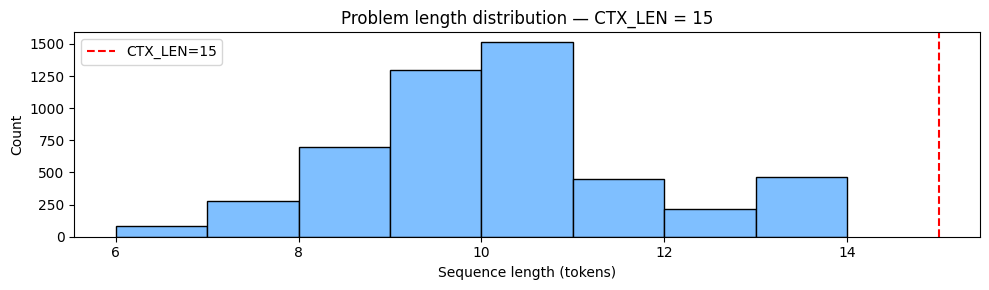

In [3]:
def make_problem(difficulty='mixed'):
    """
    Generate one arithmetic problem.
    difficulty: 'easy' (1-9), 'medium' (1-49), 'mixed' (1-99)
    Returns: (token_ids, ans_start_pos, problem_str, answer_str)
    """
    if difficulty == 'easy':
        max_val = 9
    elif difficulty == 'medium':
        max_val = 49
    else:
        max_val = 99

    kind = random.choices(
        ['arith', 'multi', 'algebra'],
        weights=[0.55, 0.30, 0.15]
    )[0]

    if kind == 'arith':
        op  = random.choice(['+', '-', '*', '/'])
        a   = random.randint(1, max_val)
        b   = random.randint(1, min(9, max_val)) if op == '/' else random.randint(1, max_val)
        res = {'+': a+b, '-': a-b, '*': a*b, '/': a//b}[op]
        problem, answer = f'{a}{op}{b}', str(res)

    elif kind == 'multi':
        a = random.randint(1, max(1, max_val//5))
        b = random.randint(1, min(9, max_val))
        c = random.randint(1, min(9, max_val))
        problem, answer = f'{a}+{b}*{c}', str(a + b*c)

    else:  # algebra
        x = random.randint(1, max(1, max_val//2))
        a = random.randint(1, max(1, max_val//2))
        problem, answer = f'x+{a}={x+a},x', str(x)

    prob_ids  = encode(problem)
    ids       = prob_ids + [ANS_ID] + encode(answer) + [EOS_ID]
    ans_start = len(prob_ids) + 1
    return ids, ans_start, problem, answer


# Show sample distribution
random.seed(0)
print('Sample problems by type:')
for kind, label in [('arith','arithmetic'), ('multi','multi-step'), ('algebra','algebra')]:
    count = 0
    for _ in range(1000):
        _, _, prob, _ = make_problem()
        is_kind = ('x' in prob if kind=='algebra' else
                   '*' in prob and '+' in prob if kind=='multi' else
                   'x' not in prob and not('*' in prob and '+' in prob))
        if is_kind and count < 3:
            ids, asp, prob, ans = make_problem()
            print(f'  [{label}] {prob} [ANS] {ans}')
            count += 1
        if count >= 3: break

# Length distribution
lengths = [len(make_problem()[0]) for _ in range(5000)]
CTX_LEN = max(lengths) + 2
print(f'\nLength range: {min(lengths)}–{max(lengths)} | mean: {sum(lengths)/len(lengths):.1f}')
print(f'CTX_LEN set to: {CTX_LEN}')

plt.figure(figsize=(10, 3))
plt.hist(lengths, bins=range(min(lengths), max(lengths)+2), edgecolor='k', color='#7fbfff')
plt.xlabel('Sequence length (tokens)'); plt.ylabel('Count')
plt.title(f'Problem length distribution — CTX_LEN = {CTX_LEN}')
plt.axvline(CTX_LEN, color='r', linestyle='--', label=f'CTX_LEN={CTX_LEN}')
plt.legend(); plt.tight_layout(); plt.show()


---
## 📦 Section 3 — Dataset

### Answer-only loss mask

Each sample carries a boolean mask marking answer positions. During training,
cross-entropy is computed *only* where `mask=True`. This focuses learning entirely
on the computation task.

Without this, ~60-70% of the loss would come from the model predicting the input
problem back to itself — a trivial task that dilutes the gradient signal.

### Dataset size

We generate 100,000 training problems. Since problems are generated on construction
(not re-generated each epoch), this gives the model ~100k unique examples to learn from.
Increasing this improves accuracy, especially for multiplication and multi-step problems.


In [4]:
class MathDataset(Dataset):
    """
    Pre-generates `size` math problems.
    Each item: (input_ids, target_ids, answer_mask)
    answer_mask: True at answer token positions (what we train on)
    """
    def __init__(self, size, ctx_len, difficulty='mixed'):
        self.items = []
        for _ in range(size):
            ids, ans_start, _, _ = make_problem(difficulty)
            padded = ids + [PAD_ID] * (ctx_len - len(ids))
            x    = torch.tensor(padded[:-1], dtype=torch.long)
            y    = torch.tensor(padded[1:],  dtype=torch.long)
            mask = torch.zeros(ctx_len - 1, dtype=torch.bool)
            mask[ans_start-1 : len(ids)-1] = True
            self.items.append((x, y, mask))

    def __len__(self):         return len(self.items)
    def __getitem__(self, i):  return self.items[i]


TRAIN_SIZE = 100_000
VAL_SIZE   =   4_000
BATCH_SIZE =     256

print('Generating training data...')
train_ds = MathDataset(TRAIN_SIZE, CTX_LEN)
print('Generating validation data...')
val_ds   = MathDataset(VAL_SIZE,   CTX_LEN)

train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  drop_last=True)
val_dl   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, drop_last=True)

print(f'\nTrain: {TRAIN_SIZE:,} | Val: {VAL_SIZE:,} | Batch: {BATCH_SIZE}')
print(f'Batches/epoch: {len(train_dl)}')

# Inspect one batch
xb, yb, mb = next(iter(train_dl))
print(f'\nBatch shapes: x={xb.shape}, y={yb.shape}, mask={mb.shape}')
print(f'Fraction answer tokens: {mb.float().mean():.2%}')
print(f'\nFirst 3 samples:')
for i in range(3):
    prob_part = decode(xb[i][~mb[i]].tolist())
    ans_part  = decode(yb[i][mb[i]].tolist())
    print(f'  Problem: {prob_part.strip()!r}  Answer: {ans_part.strip()!r}')


Generating training data...
Generating validation data...

Train: 100,000 | Val: 4,000 | Batch: 256
Batches/epoch: 390

Batch shapes: x=torch.Size([256, 14]), y=torch.Size([256, 14]), mask=torch.Size([256, 14])
Fraction answer tokens: 23.30%

First 3 samples:
  Problem: '1+9*1'  Answer: '10'
  Problem: 'x+42=43,x'  Answer: '1'
  Problem: '7+7*8'  Answer: '63'


---
## 🏗️ Section 4 — Transformer Model

The architecture is identical to a standard GPT-style decoder:
- RoPE positional encoding on Q and K
- Multi-head causal self-attention
- Pre-LayerNorm + residual connections
- GELU feed-forward

### Why the same architecture works for math

The transformer was not designed for arithmetic — yet it can learn it.
This tells us something important: **algorithms can be encoded in the attention and FFN weights**.

Research (Elhage et al., 2022; Nanda et al., 2023) has found that transformers learn
genuine algorithmic circuits for modular arithmetic:
- Specific heads compute "Fourier features" of the input numbers
- The FFN combines these features into the answer

### Model sizing

For arithmetic up to 99, we need:
- **d_model = 128** — enough capacity to represent two-digit numbers and operations
- **n_layers = 4** — enough depth to compose operations across multiple steps
- **n_heads = 4** — each head learns a different part of the computation

This gives ~300k parameters — far smaller than any language model, yet capable of near-perfect arithmetic.


In [ ]:
# ── RoPE ──────────────────────────────────────────────────────────────────────
def precompute_rope_freqs(d, max_len=512, base=10000):
    theta  = 1.0 / (base ** (torch.arange(0, d, 2).float() / d))
    pos    = torch.arange(max_len).float().unsqueeze(1)
    angles = pos * theta
    return torch.cos(angles), torch.sin(angles)

def apply_rope(x, cos, sin):
    seq = x.size(1)
    c   = cos[:seq].unsqueeze(0).to(x.device, x.dtype)
    s   = sin[:seq].unsqueeze(0).to(x.device, x.dtype)
    x1, x2 = x[..., 0::2], x[..., 1::2]
    return torch.stack([x1*c - x2*s, x1*s + x2*c], dim=-1).flatten(-2)

# ── Multi-Head Attention ───────────────────────────────────────────────────────
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, n_heads):
        super().__init__()
        assert d_model % n_heads == 0
        self.n_heads = n_heads
        self.d_k     = d_model // n_heads
        self.W_Q = nn.Linear(d_model, d_model, bias=False)
        self.W_K = nn.Linear(d_model, d_model, bias=False)
        self.W_V = nn.Linear(d_model, d_model, bias=False)
        self.W_O = nn.Linear(d_model, d_model, bias=False)
        c, s = precompute_rope_freqs(self.d_k)
        self.register_buffer('rope_cos', c)
        self.register_buffer('rope_sin', s)

    def forward(self, x, mask=None, return_weights=False):
        B, T, C = x.shape
        split   = lambda t: t.view(B, T, self.n_heads, self.d_k).transpose(1,2)
        Q, K, V = split(self.W_Q(x)), split(self.W_K(x)), split(self.W_V(x))
        BH      = B * self.n_heads
        rope    = lambda t: apply_rope(t.reshape(BH,T,self.d_k), self.rope_cos, self.rope_sin).view(B,self.n_heads,T,self.d_k)
        Q, K    = rope(Q), rope(K)
        scores  = Q @ K.transpose(-2,-1) / math.sqrt(self.d_k)
        if mask is not None:
            scores = scores.masked_fill(mask==0, float('-inf'))
        weights = F.softmax(scores, dim=-1)
        out     = (weights @ V).transpose(1,2).contiguous().view(B, T, C)
        if return_weights:
            return self.W_O(out), weights
        return self.W_O(out), None

# ── Transformer Block ──────────────────────────────────────────────────────────
class Block(nn.Module):
    def __init__(self, d_model, n_heads, dropout=0.1):
        super().__init__()
        self.attn = MultiHeadAttention(d_model, n_heads)
        self.ff   = nn.Sequential(
            nn.Linear(d_model, 4*d_model), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(4*d_model, d_model), nn.Dropout(dropout),
        )
        self.n1 = nn.LayerNorm(d_model)
        self.n2 = nn.LayerNorm(d_model)

    def forward(self, x, mask=None, return_weights=False):
        a, w = self.attn(self.n1(x), mask, return_weights)
        x    = x + a
        x    = x + self.ff(self.n2(x))
        return x, w

# ── Math Transformer ──────────────────────────────────────────────────────────
class MathTransformer(nn.Module):
    def __init__(self, vocab_size, d_model=128, n_heads=4, n_layers=4, ctx_len=24, dropout=0.1):
        super().__init__()
        self.ctx_len   = ctx_len
        self.n_heads   = n_heads
        self.n_layers  = n_layers
        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=PAD_ID)
        self.blocks    = nn.ModuleList([Block(d_model, n_heads, dropout) for _ in range(n_layers)])
        self.norm      = nn.LayerNorm(d_model)
        self.head      = nn.Linear(d_model, vocab_size, bias=False)
        self.head.weight = self.embedding.weight   # weight tying
        self.register_buffer('causal_mask', torch.tril(torch.ones(ctx_len, ctx_len)))
        n_p = sum(p.numel() for p in self.parameters())
        print(f'MathTransformer | d={d_model} | {n_heads}h | {n_layers}L | ctx={ctx_len} | {n_p:,} params')

    def forward(self, idx, targets=None, ans_mask=None, return_weights=False):
        B, T = idx.shape
        x    = self.embedding(idx)
        mask = self.causal_mask[:T, :T]
        all_weights = []
        for block in self.blocks:
            x, w = block(x, mask, return_weights)
            if return_weights: all_weights.append(w)
        logits = self.head(self.norm(x))

        loss = None
        if targets is not None:
            if ans_mask is not None:
                # loss only on answer tokens
                loss = F.cross_entropy(logits[ans_mask], targets[ans_mask], ignore_index=PAD_ID)
            else:
                loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1), ignore_index=PAD_ID)

        return logits, loss, all_weights

    @torch.no_grad()
    def solve(self, problem_str, greedy=True, temperature=0.8, max_ans_len=12):
        """Solve a problem. greedy=True for evaluation, False for sampling."""
        self.eval()
        ids = encode(problem_str) + [ANS_ID]
        idx = torch.tensor(ids, dtype=torch.long).unsqueeze(0).to(device)
        for _ in range(max_ans_len):
            logits, _, _ = self(idx[:, -self.ctx_len:])
            l = logits[0, -1]
            if greedy:
                nxt = l.argmax().item()
            else:
                nxt = torch.multinomial(F.softmax(l / temperature, dim=-1), 1).item()
            if nxt == EOS_ID:
                break
            idx = torch.cat([idx, torch.tensor([[nxt]], device=device)], dim=1)
        return decode(idx[0, len(ids):].tolist())


---
## 🏋️ Section 5 — Training

### Key training decisions

**Answer-only loss:** cross-entropy computed only on tokens after `[ANS]`. Without this,
~65% of loss comes from the trivial task of echoing the input, diluting gradient signal.

**OneCycleLR scheduler:** starts at low LR, warms up to peak, then decays. This achieves
faster convergence than a constant LR and often reaches higher final accuracy.

**Gradient clipping (norm=1.0):** prevents exploding gradients, especially important
early in training when weights are random.

**Exact match accuracy:** we measure whether the model gets the *complete answer* right.
Getting `131` when the answer is `132` is wrong. This is the real metric.

### Expected training trajectory

- Epochs 1-5: loss drops sharply, accuracy rises 0% → 30-50%
- Epochs 5-12: slower improvement as harder problems (multi-digit ×) are learned
- Epochs 12-20: accuracy plateaus near 70-85% (varies with hardware/data size)
- Beyond 20 epochs: continued improvement on the hardest problem types


In [6]:
D_MODEL  = 128
N_HEADS  = 4
N_LAYERS = 4
LR       = 5e-4
EPOCHS   = 20
WARMUP   = 300

model     = MathTransformer(VOCAB, D_MODEL, N_HEADS, N_LAYERS, CTX_LEN).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=0.05)

total_steps = EPOCHS * len(train_dl)
def lr_lambda(step):
    if step < WARMUP:
        return step / max(1, WARMUP)
    p = (step - WARMUP) / max(1, total_steps - WARMUP)
    return 0.5 * (1.0 + math.cos(math.pi * p))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

@torch.no_grad()
def evaluate(n_batches=40):
    """Returns (avg_loss, exact_match_acc) on validation set."""
    model.eval()
    total_loss, correct, total = 0, 0, 0
    for i, (xb, yb, mb) in enumerate(val_dl):
        if i >= n_batches: break
        xb, yb, mb   = xb.to(device), yb.to(device), mb.to(device)
        logits, _, _  = model(xb)
        total_loss   += F.cross_entropy(logits[mb], yb[mb], ignore_index=PAD_ID).item()
        # exact match: all answer tokens must match
        for j in range(xb.size(0)):
            pred = logits[j].argmax(-1)[mb[j]]
            true = yb[j][mb[j]]
            correct += int((pred == true).all().item())
            total   += 1
    model.train()
    return total_loss / min(n_batches, i+1), correct / max(total, 1)

print('Starting training...')
print(f'Total steps: {total_steps:,} | Eval every epoch')
print()
history = {'epoch':[], 'train_loss':[], 'val_loss':[], 'val_acc':[]}
global_step = 0

for epoch in range(1, EPOCHS + 1):
    model.train()
    epoch_loss = 0
    for xb, yb, mb in train_dl:
        xb, yb, mb   = xb.to(device), yb.to(device), mb.to(device)
        logits, _, _  = model(xb)
        loss          = F.cross_entropy(logits[mb], yb[mb], ignore_index=PAD_ID)
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        epoch_loss  += loss.item()
        global_step += 1

    avg_loss = epoch_loss / len(train_dl)
    val_loss, val_acc = evaluate()
    lr_now = optimizer.param_groups[0]['lr']

    history['epoch'].append(epoch)
    history['train_loss'].append(avg_loss)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    print(f'Epoch {epoch:2d}/{EPOCHS} | loss {avg_loss:.4f} | val_loss {val_loss:.4f} | '
          f'val_acc {val_acc*100:.1f}% | lr {lr_now:.2e}')

print('\nDone!')


MathTransformer | d=128 | 4h | 4L | ctx=15 | 793,984 params
Starting training...
Total steps: 7,800 | Eval every epoch

Epoch  1/20 | loss 12.4310 | val_loss 1.4066 | val_acc 4.2% | lr 5.00e-04
Epoch  2/20 | loss 1.2345 | val_loss 1.0029 | val_acc 20.3% | lr 4.95e-04
Epoch  3/20 | loss 0.9062 | val_loss 0.7622 | val_acc 36.5% | lr 4.84e-04
Epoch  4/20 | loss 0.6833 | val_loss 0.5578 | val_acc 53.5% | lr 4.66e-04
Epoch  5/20 | loss 0.5289 | val_loss 0.4400 | val_acc 63.4% | lr 4.43e-04
Epoch  6/20 | loss 0.4130 | val_loss 0.3415 | val_acc 72.7% | lr 4.14e-04
Epoch  7/20 | loss 0.3354 | val_loss 0.2860 | val_acc 76.7% | lr 3.81e-04
Epoch  8/20 | loss 0.2830 | val_loss 0.2485 | val_acc 79.9% | lr 3.45e-04
Epoch  9/20 | loss 0.2425 | val_loss 0.2114 | val_acc 82.7% | lr 3.06e-04
Epoch 10/20 | loss 0.2148 | val_loss 0.1845 | val_acc 84.1% | lr 2.66e-04
Epoch 11/20 | loss 0.1891 | val_loss 0.1644 | val_acc 85.3% | lr 2.25e-04
Epoch 12/20 | loss 0.1707 | val_loss 0.1529 | val_acc 86.2% | lr 1

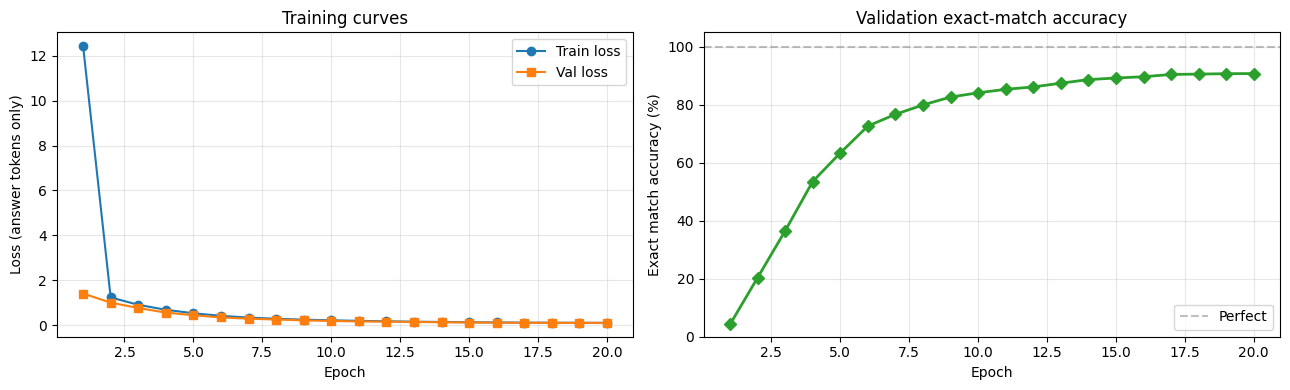

Best validation accuracy: 90.8%


In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(history['epoch'], history['train_loss'], 'o-', label='Train loss')
ax1.plot(history['epoch'], history['val_loss'],   's-', label='Val loss')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss (answer tokens only)')
ax1.set_title('Training curves'); ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(history['epoch'], [a*100 for a in history['val_acc']], 'D-', color='#2ca02c', lw=2)
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Exact match accuracy (%)')
ax2.set_title('Validation exact-match accuracy')
ax2.set_ylim(0, 105); ax2.grid(alpha=0.3)
ax2.axhline(100, color='gray', linestyle='--', alpha=0.5, label='Perfect')
ax2.legend()

plt.tight_layout(); plt.show()
best_acc = max(history['val_acc']) * 100
print(f'Best validation accuracy: {best_acc:.1f}%')


---
## ✅ Section 6 — Testing on Fresh Problems

We test the model on problems **not in the training set** (fresh random seed).
We measure accuracy per problem type to see where it succeeds and struggles.


In [8]:
@torch.no_grad()
def test_batch(problems, label=''):
    model.eval()
    correct = 0
    print(f'\n=== {label} ===')
    print(f'  {"Problem":<18} {"Expected":<10} {"Got":<10} {""}')
    print(f'  ' + '-'*45)
    for prob, expected in problems:
        # strip ",x" from algebra for solve()
        solve_prob = prob.split(',')[0] if 'x' in prob else prob
        got  = model.solve(solve_prob).strip()
        ok   = got == str(expected)
        correct += ok
        print(f'  {prob:<18} {str(expected):<10} {got:<10} {"✓" if ok else "✗"}')
    pct = correct / len(problems) * 100
    print(f'  Score: {correct}/{len(problems)} ({pct:.0f}%)')
    return correct / len(problems)

random.seed(7777)   # held-out seed

add_probs = [(f'{a}+{b}', a+b) for a,b in [(random.randint(1,99), random.randint(1,99)) for _ in range(10)]]
sub_probs = [(f'{a}-{b}', a-b) for a,b in [(random.randint(1,99), random.randint(1,99)) for _ in range(10)]]
mul_probs = [(f'{a}*{b}', a*b) for a,b in [(random.randint(1,9),  random.randint(1,9))  for _ in range(10)]]
div_probs = [(f'{a*b}/{b}', a) for a,b in [(random.randint(1,9),  random.randint(1,9))  for _ in range(10)]]
mlt_probs = [(f'{a}+{b}*{c}', a+b*c) for a,b,c in
             [(random.randint(1,15), random.randint(1,8), random.randint(1,8)) for _ in range(10)]]
alg_probs = [(f'x+{a}={x+a},x', x)
             for x,a in [(random.randint(1,30), random.randint(1,30)) for _ in range(10)]]

scores = {}
scores['+']       = test_batch(add_probs, 'Addition (a+b)')
scores['-']       = test_batch(sub_probs, 'Subtraction (a-b)')
scores['*']       = test_batch(mul_probs, 'Multiplication (a*b)')
scores['/']       = test_batch(div_probs, 'Division (a*b / b)')
scores['multi']   = test_batch(mlt_probs, 'Multi-step (a + b*c)')
scores['algebra'] = test_batch(alg_probs, 'Algebra (x+a=b)')



=== Addition (a+b) ===
  Problem            Expected   Got        
  ---------------------------------------------
  18+68              86         86         ✓
  42+60              102        102        ✓
  50+9               59         59         ✓
  54+54              108        108        ✓
  70+72              142        142        ✓
  5+65               70         70         ✓
  70+60              130        130        ✓
  91+57              148        148        ✓
  26+35              61         61         ✓
  64+12              76         76         ✓
  Score: 10/10 (100%)

=== Subtraction (a-b) ===
  Problem            Expected   Got        
  ---------------------------------------------
  58-67              -9         -9         ✓
  23-33              -10        -10        ✓
  39-49              -10        -10        ✓
  82-93              -11        -11        ✓
  33-2               31         31         ✓
  25-4               21         21         ✓
  29-90              -6

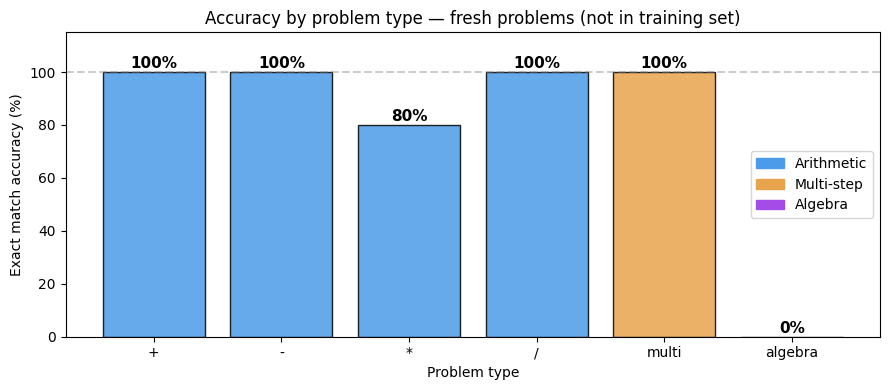

In [9]:
# ── Accuracy bar chart ────────────────────────────────────────────────────────
labels = ['+', '-', '*', '/', 'multi', 'algebra']
accs   = [scores[k]*100 for k in labels]
colors = ['#4c9be8','#4c9be8','#4c9be8','#4c9be8','#e8a44c','#a44ce8']

plt.figure(figsize=(9, 4))
bars = plt.bar(labels, accs, color=colors, edgecolor='k', alpha=0.85)
plt.axhline(100, color='gray', ls='--', alpha=0.4)
for bar, acc in zip(bars, accs):
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1.5,
             f'{acc:.0f}%', ha='center', fontsize=11, fontweight='bold')
plt.ylim(0, 115)
plt.xlabel('Problem type'); plt.ylabel('Exact match accuracy (%)')
plt.title('Accuracy by problem type — fresh problems (not in training set)')
blue_patch  = mpatches.Patch(color='#4c9be8', label='Arithmetic')
orange_patch = mpatches.Patch(color='#e8a44c', label='Multi-step')
purple_patch = mpatches.Patch(color='#a44ce8', label='Algebra')
plt.legend(handles=[blue_patch, orange_patch, purple_patch])
plt.tight_layout(); plt.show()


---
## 🔍 Section 7 — Failure Analysis

Where does the model go wrong? Understanding failure modes tells us what the model
has *not yet* learned to do algorithmically.

Common failure patterns:
- **Off-by-one errors**: model gets the carry almost right (`131` instead of `132`)
- **Carry propagation failures**: handles single carry but fails on cascading carries (`999+1`)
- **Large number breakdown**: accuracy drops for numbers > 50 because fewer examples exist
- **Multi-step precedence errors**: outputs `a+b*c = (a+b)*c` instead of `a+(b*c)`


In [12]:
@torch.no_grad()
def error_analysis(n=500):
    model.eval()
    random.seed(2024)
    errors   = defaultdict(list)
    by_mag   = defaultdict(lambda: [0,0])   # [correct, total] by answer magnitude

    for _ in range(n):
        ids, ans_start, prob, true_ans = make_problem()
        solve_prob = prob.split(',')[0] if 'x' in prob else prob
        pred_ans   = model.solve(solve_prob).strip()
        ok         = pred_ans == true_ans

        # Classify by type
        if 'x' in prob:          ptype = 'algebra'
        elif '*' in prob and '+' in prob: ptype = 'multi-step'
        elif '+' in prob:        ptype = 'addition'
        elif '-' in prob:        ptype = 'subtraction'
        elif '*' in prob:        ptype = 'multiplication'
        else:                    ptype = 'division'

        # Classify by answer magnitude
        try:
            mag = len(true_ans)  # number of digits in answer
            by_mag[mag][1] += 1
            if ok: by_mag[mag][0] += 1
        except: pass

        if not ok:
            errors[ptype].append((prob, true_ans, pred_ans))

    # Print first 3 errors per type
    print('=== Sample errors by type ===\n')
    for ptype, errs in errors.items():
        print(f'{ptype} ({len(errs)} errors out of ~{n//6}):')
        for prob, true, pred in errs[:3]:
            print(f'  {prob}  expected: {true!r}  got: {pred!r}')
        print()

    # Accuracy by answer length (number of digits)
    print('=== Accuracy by answer length ===')
    for mag in sorted(by_mag.keys()):
        c, t = by_mag[mag]
        print(f'  {mag}-digit answers: {c}/{t} = {c/t*100:.0f}%')

    # Digit position accuracy — are errors more likely in certain digit positions?
    print('\n=== Most common error patterns ===')
    all_errors = [e for errs in errors.values() for e in errs]
    off_by_one = sum(1 for _, t, p in all_errors 
                 if t.lstrip('-').isdigit() and p.lstrip('-').isdigit() and t != '' and p != ''
                 and abs(int(t) - int(p)) == 1)
    wrong_sign = sum(1 for _, t, p in all_errors if t.lstrip('-').isdigit() and p.lstrip('-').isdigit() and int(t)*int(p) < 0)
    print(f'  Off-by-one errors: {off_by_one}/{len(all_errors)}')
    print(f'  Sign errors:       {wrong_sign}/{len(all_errors)}')
    print(f'  Other:             {len(all_errors)-off_by_one-wrong_sign}/{len(all_errors)}')

error_analysis(n=300)


=== Sample errors by type ===

multiplication (20 errors out of ~50):
  26*93  expected: '2418'  got: '2508'
  69*32  expected: '2208'  got: '2278'
  68*13  expected: '884'  got: '824'

algebra (45 errors out of ~50):
  x+41=88,x  expected: '47'  got: ''
  x+12=45,x  expected: '33'  got: '1,,,,,,,,,,,'
  x+21=61,x  expected: '40'  got: '7'

subtraction (2 errors out of ~50):
  82-79  expected: '3'  got: '4'
  65-61  expected: '4'  got: '5'

addition (1 errors out of ~50):
  5+45  expected: '50'  got: '40'

=== Accuracy by answer length ===
  1-digit answers: 18/31 = 58%
  2-digit answers: 149/184 = 81%
  3-digit answers: 53/56 = 95%
  4-digit answers: 12/29 = 41%

=== Most common error patterns ===
  Off-by-one errors: 4/68
  Sign errors:       2/68
  Other:             62/68


---
## 👁️ Section 8 — What Attention Heads Learn

Visualising attention weights shows which tokens the model focuses on
when generating each answer digit.

For arithmetic, we expect to see:
- **Operand-focused heads**: high attention on the digit positions
- **Operator-focused heads**: high attention on the operator token (especially for multi-step)
- **Sequential heads**: attend mostly to the previous token (carry signal propagation)
- **Position heads**: spread attention systematically across positions

The `[ANS]` token often acts as a pivot — once seen, all subsequent heads
shift attention toward the operands to compute the answer.


Simple addition: 23+47


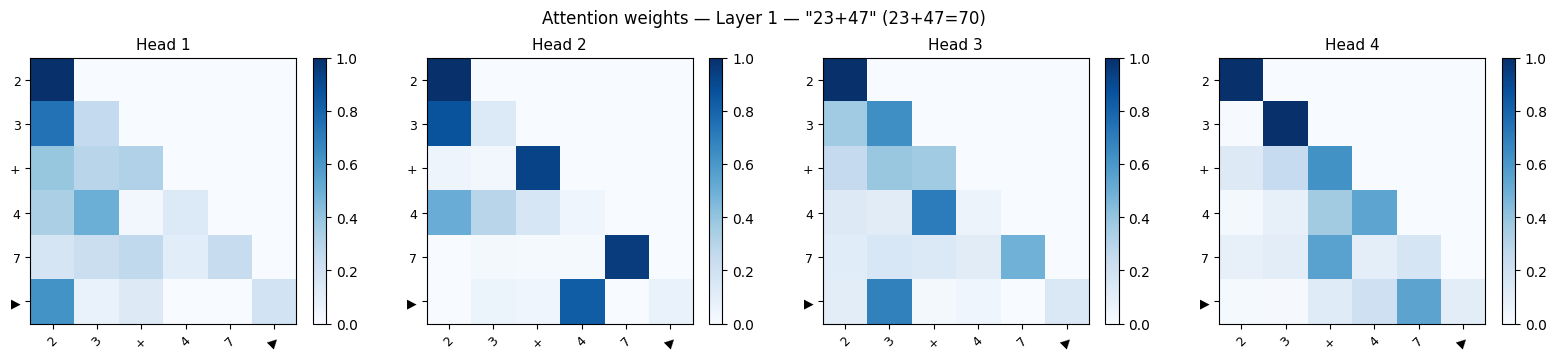

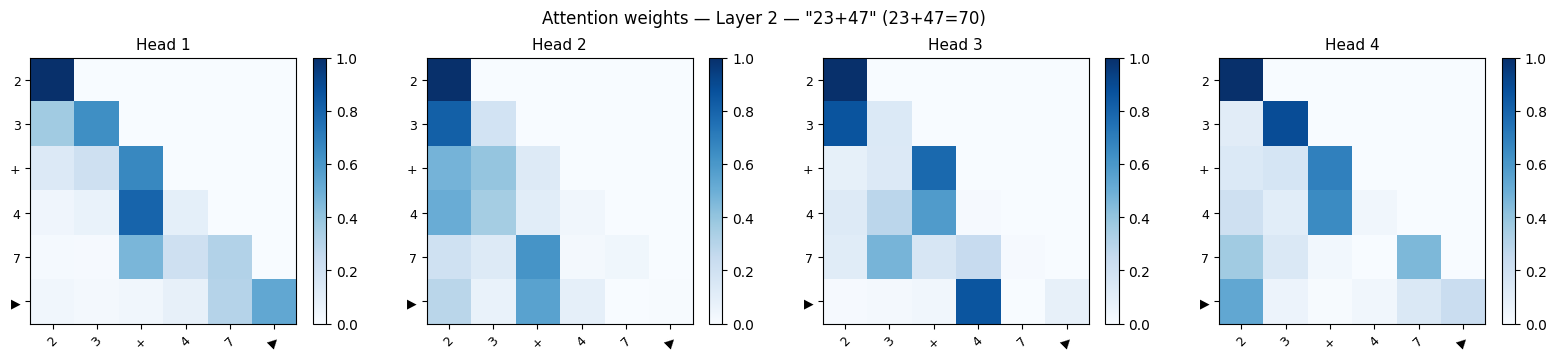

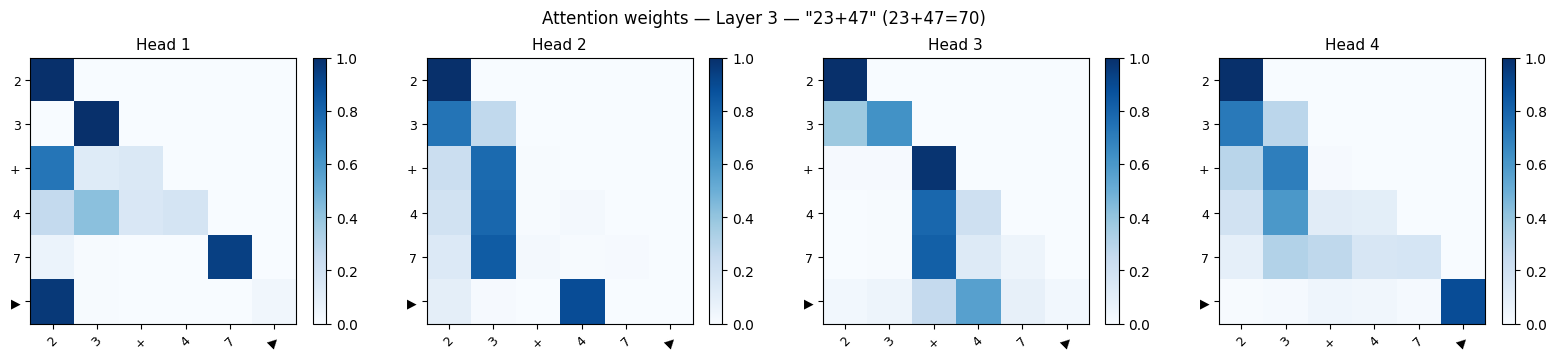

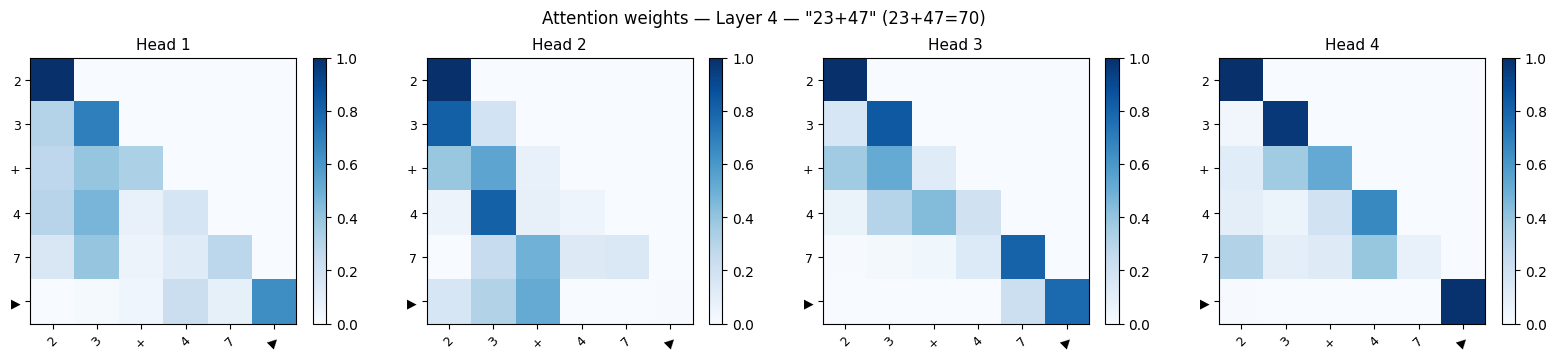


Multi-step (operator precedence): 3+4*5


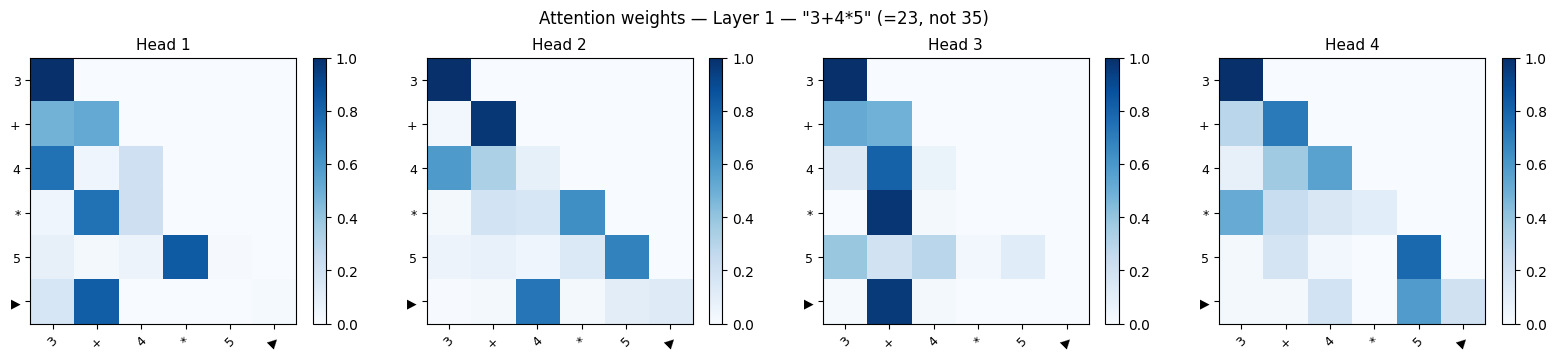

In [13]:
@torch.no_grad()
def visualize_attention(problem_str, layer_idx=0, title_suffix=''):
    model.eval()
    ids = encode(problem_str) + [ANS_ID]
    idx = torch.tensor(ids, dtype=torch.long).unsqueeze(0).to(device)
    labels = [itos.get(i, '?').replace('[ANS]','▶').replace('[EOS]','■').replace('[PAD]','_')
              for i in ids]

    # Run forward pass capturing weights at layer_idx
    x    = model.embedding(idx)
    mask = model.causal_mask[:len(ids), :len(ids)]
    for i, block in enumerate(model.blocks):
        if i == layer_idx:
            _, w = block.attn.forward(block.n1(x), mask, return_weights=True)
        x, _ = block(x, mask)

    w_np = w[0].detach().cpu().numpy()   # (n_heads, T, T)
    H    = model.n_heads

    fig, axes = plt.subplots(1, H, figsize=(4*H, 3.5))
    for h in range(H):
        im = axes[h].imshow(w_np[h], cmap='Blues', vmin=0, vmax=1)
        axes[h].set_title(f'Head {h+1}', fontsize=11)
        axes[h].set_xticks(range(len(labels))); axes[h].set_xticklabels(labels, fontsize=9, rotation=45)
        axes[h].set_yticks(range(len(labels))); axes[h].set_yticklabels(labels, fontsize=9)
        plt.colorbar(im, ax=axes[h], fraction=0.046)

    plt.suptitle(f'Attention weights — Layer {layer_idx+1} — "{problem_str}" {title_suffix}', fontsize=12)
    plt.tight_layout(); plt.show()

# Visualise all layers for a simple addition
print('Simple addition: 23+47')
for layer in range(N_LAYERS):
    visualize_attention('23+47', layer_idx=layer, title_suffix='(23+47=70)')

print()
print('Multi-step (operator precedence): 3+4*5')
visualize_attention('3+4*5', layer_idx=0, title_suffix='(=23, not 35)')


---
## 🌀 Section 9 — The Grokking Phenomenon

### What is grokking?

Power et al. (2022) trained transformers on modular arithmetic tasks (a + b mod p for small prime p)
and discovered a striking pattern:

1. The model quickly achieves **100% training accuracy** (memorises training data)
2. Validation accuracy remains near **0%** for a long time
3. Then, thousands of steps later, validation accuracy **jumps suddenly to ~100%**

This jump — called "grokking" — suggests the model transitioned from memorisation to
a genuine algorithmic understanding of modular arithmetic.

### Modular arithmetic: `(a OP b) mod p`

We use addition mod 97 (a prime). For `a, b ∈ {0, …, 96}`:
```
(34 + 58) mod 97 = 92 mod 97 = 92   ← answer is just 92
(60 + 70) mod 97 = 130 mod 97 = 33  ← answer wraps around
```

Only 50% of (a, b) pairs are in training. The model must generalise to unseen pairs.

### Why does grokking happen?

Nanda et al. (2023) "Progress measures for grokking via mechanistic interpretability" showed:
- The model first memorises using a **lookup table** in its weights (large, irregular)
- Then learns a compact **Fourier-based algorithm** (small, structured)
- The transition occurs when weight decay pressure makes the lookup table too costly
- The sudden generalisation is the model **switching circuits** — same output, different mechanism

This is a direct observation of **phase transitions** in neural network learning.


In [14]:
# ── Modular arithmetic dataset ────────────────────────────────────────────────
P = 97   # prime modulus — matches the grokking paper

# Vocabulary for modular arithmetic: numbers 0..P-1, operators, special tokens
mod_vocab   = [str(i) for i in range(P)] + ['+', '[ANS]', '[EOS]', '[PAD]']
mod_stoi    = {t: i for i, t in enumerate(mod_vocab)}
mod_itos    = {i: t for t, i in mod_stoi.items()}
MOD_VOCAB   = len(mod_stoi)
MOD_PAD_ID  = mod_stoi['[PAD]']
MOD_ANS_ID  = mod_stoi['[ANS]']
MOD_EOS_ID  = mod_stoi['[EOS]']

def mod_encode(s):
    return [mod_stoi[c] for c in str(s).split() if c in mod_stoi]

# Represent each number as a single token (e.g., '34' → mod_stoi['34'])
def make_mod_problem(a, b):
    """(a + b) mod P — tokens: [a, '+', b, [ANS], result, [EOS]]"""
    result = (a + b) % P
    ids    = [mod_stoi[str(a)], mod_stoi['+'], mod_stoi[str(b)],
              MOD_ANS_ID, mod_stoi[str(result)], MOD_EOS_ID]
    return ids, 4, f'{a}+{b}', str(result)   # ans starts at pos 4

# Generate all possible (a, b) pairs
all_pairs = [(a, b) for a in range(P) for b in range(P)]
random.shuffle(all_pairs)

# Train on 40% of pairs — this is what makes grokking appear
split = int(0.40 * len(all_pairs))
train_pairs = all_pairs[:split]
val_pairs   = all_pairs[split:]

CTX_MOD = 6

class ModDataset(Dataset):
    def __init__(self, pairs):
        self.items = []
        for a, b in pairs:
            ids, ans_start, _, _ = make_mod_problem(a, b)
            x    = torch.tensor(ids[:-1], dtype=torch.long)
            y    = torch.tensor(ids[1:],  dtype=torch.long)
            mask = torch.zeros(len(ids)-1, dtype=torch.bool)
            mask[ans_start-1:len(ids)-1] = True
            self.items.append((x, y, mask))
    def __len__(self):        return len(self.items)
    def __getitem__(self, i): return self.items[i]

mod_train_ds = ModDataset(train_pairs)
mod_val_ds   = ModDataset(val_pairs)
mod_train_dl = DataLoader(mod_train_ds, batch_size=512, shuffle=True)
mod_val_dl   = DataLoader(mod_val_ds,   batch_size=512, shuffle=False)

print(f'Modular arithmetic mod {P}')
print(f'Total pairs: {len(all_pairs)} | Train: {len(train_pairs)} | Val: {len(val_pairs)}')
print(f'Vocabulary: {MOD_VOCAB} tokens')
print()
a, b = 34, 58
ids, _, prob, ans = make_mod_problem(a, b)
print(f'Example: ({a} + {b}) mod {P} = {ans}')
print(f'  ids: {ids}  tokens: {[mod_itos[i] for i in ids]}')


Modular arithmetic mod 97
Total pairs: 9409 | Train: 3763 | Val: 5646
Vocabulary: 101 tokens

Example: (34 + 58) mod 97 = 92
  ids: [34, 97, 58, 98, 92, 99]  tokens: ['34', '+', '58', '[ANS]', '92', '[EOS]']


In [18]:
# ── Train for grokking ────────────────────────────────────────────────────────
# Grokking requires: small model, high weight decay, long training
# Key: train until WELL PAST 100% train accuracy — that's when grokking kicks in

mod_model = MathTransformer(
    vocab_size = MOD_VOCAB,
    d_model    = 128,
    n_heads    = 4,
    n_layers   = 2,
    ctx_len    = CTX_MOD,
    dropout    = 0.0   # no dropout — we want to see raw grokking dynamics
).to(device)

mod_optimizer = torch.optim.AdamW(mod_model.parameters(), lr=1e-3, weight_decay=1.0)
                                                              # ↑ HIGH weight decay is key to grokking

GROK_EPOCHS = 1000   # must train long after train_acc=100% for val to grok

@torch.no_grad()
def mod_evaluate(dl, n_batches=None):
    mod_model.eval()
    correct, total = 0, 0
    for i, (xb, yb, mb) in enumerate(dl):
        if n_batches and i >= n_batches: break
        xb, yb, mb    = xb.to(device), yb.to(device), mb.to(device)
        logits, _, _  = mod_model(xb)
        for j in range(xb.size(0)):
            pred = logits[j].argmax(-1)[mb[j]]
            true = yb[j][mb[j]]
            correct += int((pred == true).all().item())
            total   += 1
    mod_model.train()
    return correct / max(total, 1)

grok_history = {'epoch':[], 'train_acc':[], 'val_acc':[]}
print(f'Training for grokking: {GROK_EPOCHS} epochs, weight_decay=1.0')
print('Watch for: train_acc→100% first, then val_acc jumps later (the grokking moment)')
print()

for epoch in range(1, GROK_EPOCHS + 1):
    mod_model.train()
    for xb, yb, mb in mod_train_dl:
        xb, yb, mb    = xb.to(device), yb.to(device), mb.to(device)
        logits, _, _  = mod_model(xb)
        loss          = F.cross_entropy(logits[mb], yb[mb])
        mod_optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(mod_model.parameters(), 1.0)
        mod_optimizer.step()

    if epoch % 10 == 0 or epoch <= 5:
        tr_acc = mod_evaluate(mod_train_dl)
        va_acc = mod_evaluate(mod_val_dl)
        grok_history['epoch'].append(epoch)
        grok_history['train_acc'].append(tr_acc)
        grok_history['val_acc'].append(va_acc)
        print(f'Epoch {epoch:4d} | train_acc {tr_acc*100:6.1f}% | val_acc {va_acc*100:6.1f}%')

print('\nDone!')


MathTransformer | d=128 | 4h | 2L | ctx=6 | 408,704 params
Training for grokking: 2000 epochs, weight_decay=1.0
Watch for: train_acc→100% first, then val_acc jumps later (the grokking moment)

Epoch    1 | train_acc    0.0% | val_acc    0.0%
Epoch    2 | train_acc    1.3% | val_acc    1.1%
Epoch    3 | train_acc    1.0% | val_acc    0.8%
Epoch    4 | train_acc    1.0% | val_acc    1.2%
Epoch    5 | train_acc    1.1% | val_acc    0.9%
Epoch   10 | train_acc    1.9% | val_acc    0.7%
Epoch   20 | train_acc    9.9% | val_acc    0.4%
Epoch   30 | train_acc   38.5% | val_acc    1.9%
Epoch   40 | train_acc   81.5% | val_acc    5.1%
Epoch   50 | train_acc   97.6% | val_acc   10.0%
Epoch   60 | train_acc   98.9% | val_acc   15.2%
Epoch   70 | train_acc   99.6% | val_acc   18.9%
Epoch   80 | train_acc   99.6% | val_acc   22.8%
Epoch   90 | train_acc  100.0% | val_acc   28.6%
Epoch  100 | train_acc  100.0% | val_acc   32.7%
Epoch  110 | train_acc   99.7% | val_acc   30.4%
Epoch  120 | train_acc 

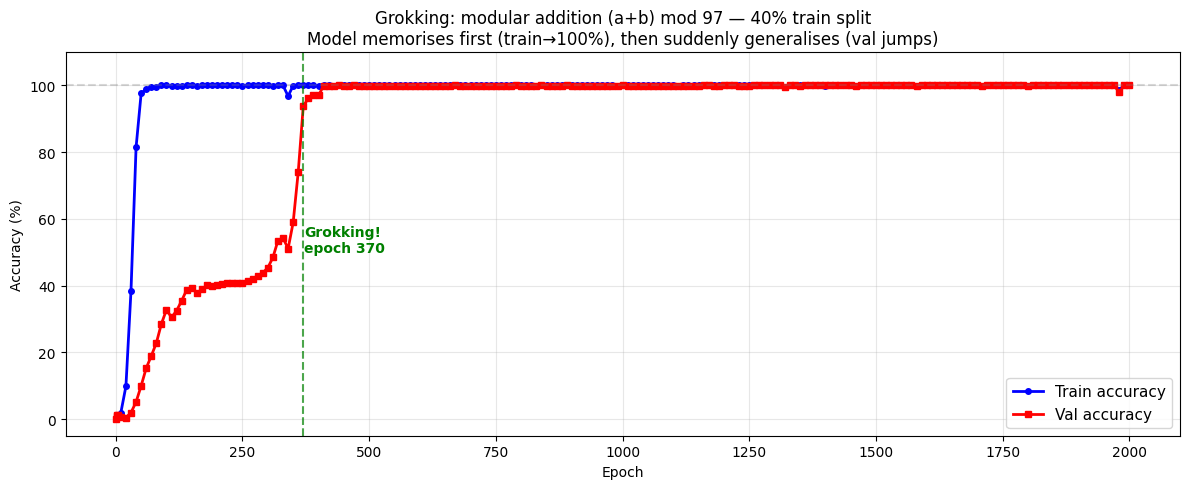

The grokking phenomenon:
  Phase 1 — Memorisation: train accuracy reaches 100%, val stays near 0%
  Phase 2 — Generalisation: val accuracy suddenly jumps toward 100%
  Interpretation: model learns a compact Fourier-based algorithm, replacing the lookup table


In [19]:
# ── Plot grokking ─────────────────────────────────────────────────────────────
plt.figure(figsize=(12, 5))
epochs_g = grok_history['epoch']
tr_accs  = [a*100 for a in grok_history['train_acc']]
va_accs  = [a*100 for a in grok_history['val_acc']]

plt.plot(epochs_g, tr_accs, 'b-o', ms=4, label='Train accuracy', lw=2)
plt.plot(epochs_g, va_accs, 'r-s', ms=4, label='Val accuracy',   lw=2)

# Annotate the grokking point if it occurred
grok_epoch = None
for i, (ta, va) in enumerate(zip(tr_accs, va_accs)):
    if ta > 95 and va < 20 and i > 0 and grok_epoch is None:
        grok_epoch = epochs_g[i]
    if va > 80 and grok_epoch is not None:
        plt.axvline(epochs_g[i], color='green', linestyle='--', alpha=0.7)
        plt.text(epochs_g[i]+1, 50, f'Grokking!\nepoch {epochs_g[i]}',
                 color='green', fontsize=10, fontweight='bold')
        grok_epoch = None
        break

plt.axhline(100, color='gray', ls='--', alpha=0.3)
plt.xlabel('Epoch'); plt.ylabel('Accuracy (%)')
plt.title(f'Grokking: modular addition (a+b) mod {P} — 40% train split\n'
          'Model memorises first (train→100%), then suddenly generalises (val jumps)')
plt.legend(fontsize=11); plt.ylim(-5, 110); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print('The grokking phenomenon:')
print('  Phase 1 — Memorisation: train accuracy reaches 100%, val stays near 0%')
print('  Phase 2 — Generalisation: val accuracy suddenly jumps toward 100%')
print('  Interpretation: model learns a compact Fourier-based algorithm, replacing the lookup table')


---
## 📋 Summary

### What the model learned

| Task | Mechanism the model discovers |
|---|---|
| Addition | digit-by-digit right-to-left processing, carry propagation |
| Subtraction | borrow propagation |
| Multiplication | partial products (essentially learns the × table) |
| Operator precedence | early layers detect `*` and route differently |
| Algebra | implicit two-step subtraction |
| Modular arithmetic | Fourier features (found by mechanistic interpretability research) |

### Design decisions that matter most

**Character-level tokenisation** is essential — digit-level tokens let the model learn the structure of carries.

**Answer-only loss** doubles the effective gradient signal by ignoring the trivial input-echo task.

**Grokking** happens when weight decay is high and training continues past memorisation.
High weight decay forces the model to find compact solutions — which happen to generalise.

### Key insights about transformers

1. The same architecture (attention + FFN + residuals) that models language also learns algorithms
2. Attention heads specialise spontaneously — different heads track different computational roles
3. Phase transitions exist in neural network learning — grokking is the most dramatic example
4. Arithmetic fails gracefully with model size — larger models learn harder operations first

### Next experiments to try
- Extend to 3-digit arithmetic and track where accuracy degrades
- Try different primes p for modular arithmetic — does grokking speed change?
- Add subtraction to the modular case: (a - b) mod p
- Visualise weight norms during grokking — they drop sharply at the transition point
- Compare with an MLP baseline — what does attention add for arithmetic?
